In [1]:
import subprocess
import numpy as np
import pandas as pd

In [2]:
def process_sample(path, MAPQ_cutoff=55, max_len=400):

    # 1. histogram counts + overflow bin
    counts = np.zeros(max_len + 1, dtype=int)

    # 2. # fragments in raw data + after MAPQ filtering
    total_raw = 0
    total_filtered = 0

    # 3. open gzipped file met subprocess
    proc = subprocess.Popen(
        ["bgzip", "-cd", path],
        stdout=subprocess.PIPE,
        text=True
    )

    # 4. iterate through lines in file
    for line in proc.stdout:

        total_raw += 1

        chr_name, start, end, mapQ, strand = line.rstrip().split("\t")

        mapQ = int(mapQ)

        # 5. MAPQ filter
        if mapQ < MAPQ_cutoff:
            continue

        total_filtered += 1

        # 6. fragment length berekenen
        start = int(start)
        end = int(end)
        length = end - start

        # 7. binning + overflow handling
        if length >= max_len:
            counts[max_len] += 1
        else:
            counts[length] += 1

    # 8. normalize by total filtered fragments
    series = pd.Series(
        counts,
        index=list(range(max_len)) + ["400+"]
    )

    series = series / total_filtered

    # 9. return both signal + QC
    return series, total_filtered, total_raw

In [3]:
s1, s1_filtered, s1_raw = process_sample("/Users/mariekevandeven/stage_fragmentomics/data/EE87786.hg38.frag.tsv.bgz")
s2, s2_filtered, s2_raw = process_sample("/Users/mariekevandeven/stage_fragmentomics/data/EE87837.hg38.frag.tsv.bgz")
s3, s3_filtered, s3_raw = process_sample("/Users/mariekevandeven/stage_fragmentomics/data/EE87887.hg38.frag.tsv.bgz")
s4, s4_filtered, s4_raw = process_sample("/Users/mariekevandeven/stage_fragmentomics/data/EE87938.hg38.frag.tsv.bgz")


In [5]:
df = pd.DataFrame({
    "EE87786": s1,
    "EE87837": s2,
    "EE87887": s3,
    "EE87938": s4
})
df = df.T

<Axes: >

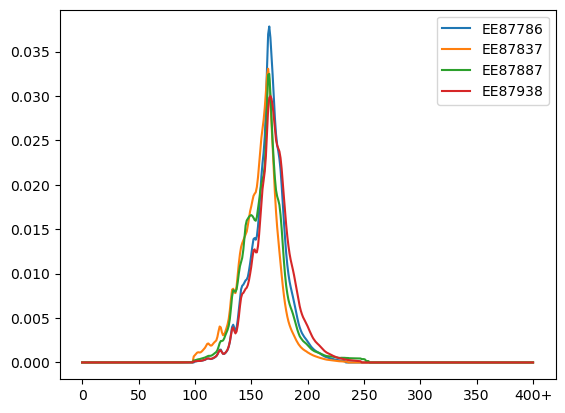

In [7]:
df.T.plot()

In [9]:
qc_df = pd.DataFrame([
   {"sample": "EE87786", "raw" : s1_raw, "filtered": s1_filtered},
    {"sample": "EE87837", "raw" : s2_raw, "filtered": s2_filtered},
    {"sample": "EE87887", "raw" : s3_raw, "filtered": s3_filtered},
    {"sample": "EE87938", "raw" : s4_raw, "filtered": s4_filtered}
])
qc_df["ratio"] = qc_df["filtered"] / qc_df["raw"]
qc_df

,sample,raw,filtered,ratio
0,EE87786,41493238,36201958,0.872478
1,EE87837,52911829,46074274,0.870775
2,EE87887,47550711,41677881,0.876493
3,EE87938,46462593,40533273,0.872385
